# 🏥 The Hidden Health Cost of Urban Inequality

**Respiratory disease, marginalization, and the absence of green**

*Notebook 6 of 8 · Project: Dos Méxicos Bajo el Mismo Sol*  
*Author: Nelly Itzel Rodríguez Ortiz · Last updated: June 2026*

Heat and pollution are visible. Hospital records are not. But when you map respiratory disease discharges across CDMX and northern EdoMex, the same north-south divide appears — now measured in human health.

## 🗂️ Where the data comes from

| Source | What we get | Period |
|---|---|---|
| **CONAPO** | Índice de Marginación (IM_2020) by AGEB | 2020 |
| **DGIS** (Secretaría de Salud) | Hospital discharges for respiratory diseases (egresos_resp) | 2023 |
| **Landsat 8 / 9** (NASA–USGS) | NDVI-derived green areas per AGEB | Summer 2025 |
| **INEGI Marco Geoestadístico** | CDMX and northern EdoMex boundaries | 2020 |

Respiratory disease discharges include all hospitalizations with a primary diagnosis in ICD-10 chapter X (J00–J99), covering pneumonia, asthma, COPD, and other acute respiratory infections.

## 🏥 What Are Respiratory Diseases (and How Do We Measure Them)?

This notebook uses hospital discharge records (*egresos hospitalarios*) from the **Dirección General de Información en Salud (DGIS)** — all discharges with a primary diagnosis classified under the **J00–J99** ICD-10 chapter (diseases of the respiratory system). This includes:

| Category | Examples |
|----------|---------|
| **Acute infections** | Pneumonia (J18), Bronchitis (J20), Influenza (J10) |
| **Chronic conditions** | Asthma (J45), COPD (J44) |
| **Other respiratory** | Upper respiratory infections (J06), Respiratory failure (J96) |

The data captures **every hospital discharge in 2023** across CDMX and northern EdoMex, aggregated by AGEB of residence. We express it as a **rate per 100,000 population** to allow fair comparison across municipalities of different sizes.

The same DGIS data was pre-joined into the master dataset at the AGEB level, which lets us cross-reference health outcomes with marginalization (CONAPO), green area (SEDEMA), and temperature (Landsat).

## ⚙️ Setup and data loading

In [33]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from scipy import stats
import geopandas as gpd
from shapely.geometry import Point

PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "master_ageb_zmvm.csv",
    low_memory=False
)

for col in ["IM_2020", "POB_TOTAL", "egresos_resp", "area_verde_total_m2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_valid = df.dropna(subset=["IM_2020"])

# AOI filter: CDMX (CVE_ENT == "09") + selected EdoMex municipios
aoi_muns = ["Ecatepec de Morelos", "Tlalnepantla de Baz", "Naucalpan de Juárez", "Nezahualcóyotl"]
df_valid = df_valid[
    (df_valid["CVE_ENT"] == 9) |
    ((df_valid["CVE_ENT"] == 15) & (df_valid["NOM_MUN"].isin(aoi_muns)))
]


print(f"Total AGEBs with IM_2020: {len(df_valid)}")
print(f"AGEBs with egresos_resp > 0: {(df_valid['egresos_resp'] > 0).sum()}")
print(f"Total respiratory discharges: {int(df_valid['egresos_resp'].sum())}")
print(f"AGEBs within AOI: {len(df_valid)}")

Total AGEBs with IM_2020: 3350
AGEBs with egresos_resp > 0: 3350
Total respiratory discharges: 2156571
AGEBs within AOI: 3350


### Aggregating by municipio

To make comparisons across indicators feasible, we aggregate all variables to the municipio level and compute the respiratory disease discharge rate per 100,000 inhabitants.

In [34]:
mun_agg = df_valid.groupby(
    ["NOM_MUN", "NOM_ENT", "entidad", "CVE_ENT", "CVE_MUN"], as_index=False
).agg(
    IM_2020=("IM_2020", "mean"),
    POB_TOTAL=("POB_TOTAL", "sum"),
    egresos_resp=("egresos_resp", "sum"),
    area_verde_total_m2=("area_verde_total_m2", "sum"),
    GM_2020=("GM_2020", lambda x: x.mode().iloc[0] if not x.mode().empty else "")
)

mun_agg["tasa_resp_100k"] = mun_agg["egresos_resp"] / mun_agg["POB_TOTAL"] * 100000
mun_agg["area_verde_pc"] = mun_agg["area_verde_total_m2"] / mun_agg["POB_TOTAL"]

print(f"Aggregated to {len(mun_agg)} municipios")
print(f"Max respiratory rate: {mun_agg['tasa_resp_100k'].max():.1f} per 100k")
print(f"Min respiratory rate: {mun_agg['tasa_resp_100k'].min():.1f} per 100k")
print(f"Median: {mun_agg['tasa_resp_100k'].median():.1f} per 100k")

# Merge municipio-level indicators
mun_indicators = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "municipio_indicators.csv")
cols_to_merge = [c for c in mun_indicators.columns if c not in ["CVE_ENT", "CVE_MUN"]]
mun_agg = mun_agg.merge(mun_indicators[cols_to_merge], on="NOM_MUN", how="left")

Aggregated to 20 municipios
Max respiratory rate: 32362.4 per 100k
Min respiratory rate: 2433.5 per 100k
Median: 9776.3 per 100k


---
## 🗺️ Respiratory Disease Discharges by Municipality

To map the spatial distribution of respiratory disease, we load the INEGI municipio shapefiles for both CDMX and EdoMex, join with our aggregated data, and create a choropleth.

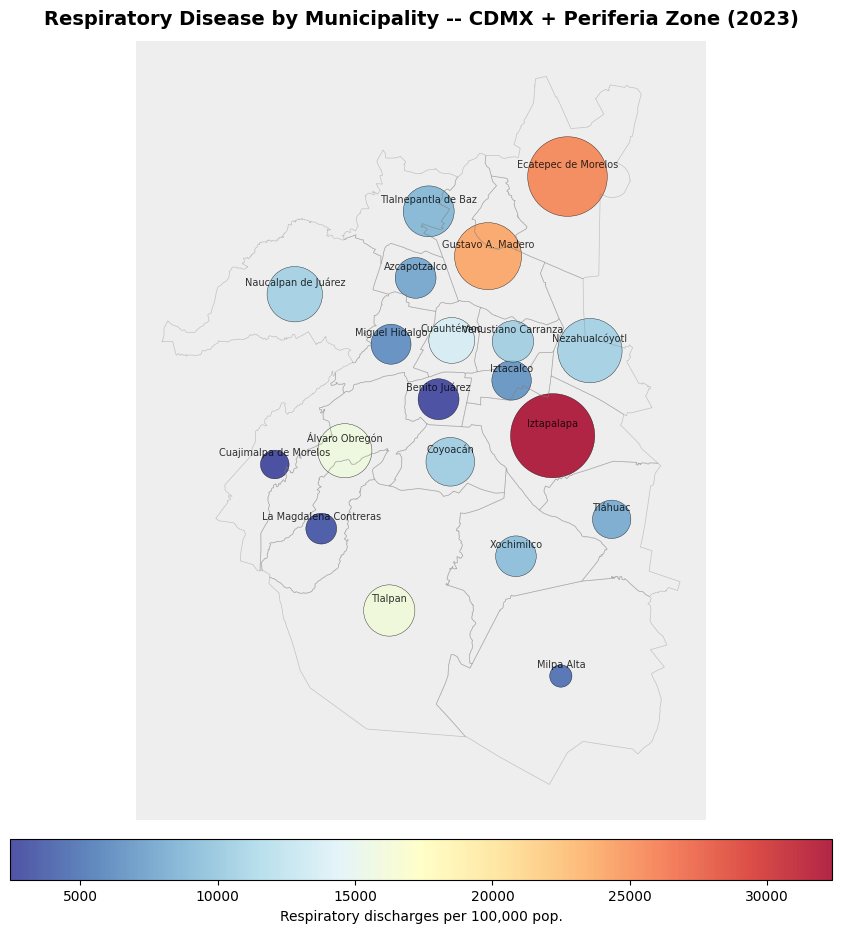

In [35]:
# Municipio-level dot map using shapefile centroids
# Only 20 dots, one per AOI municipio — avoids AGEB-level data issues

# Compute municipio centroids from the shapefiles
mun_geo = aoi_shp.copy()
mun_geo["centroid"] = mun_geo.geometry.centroid
mun_geo["x"] = mun_geo["centroid"].x
mun_geo["y"] = mun_geo["centroid"].y

# Merge with municipio-level respiratory data
mun_dots = mun_agg.merge(
    mun_geo[["NOMGEO", "x", "y"]],
    left_on="NOM_MUN", right_on="NOMGEO", how="inner"
)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#eeeeee")

# Muted municipio boundaries
aoi_shp.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.4)

# Municipio dot map
scatter = ax.scatter(
    mun_dots["x"], mun_dots["y"],
    s=mun_dots["POB_TOTAL"] / 500,
    c=mun_dots["tasa_resp_100k"],
    cmap="RdYlBu_r",
    edgecolors="black", linewidths=0.3,
    alpha=0.85
)

# Label each municipio
for _, row in mun_dots.iterrows():
    ax.annotate(
        row["NOM_MUN"],
        xy=(row["x"], row["y"]),
        fontsize=7, alpha=0.8,
        ha="center", va="bottom",
        xytext=(0, 5), textcoords="offset points"
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, orientation="horizontal", pad=0.02)
cbar.set_label("Respiratory discharges per 100,000 pop.")

ax.set_title(
    "Respiratory Disease by Municipality -- CDMX + Periferia Zone (2023)",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()


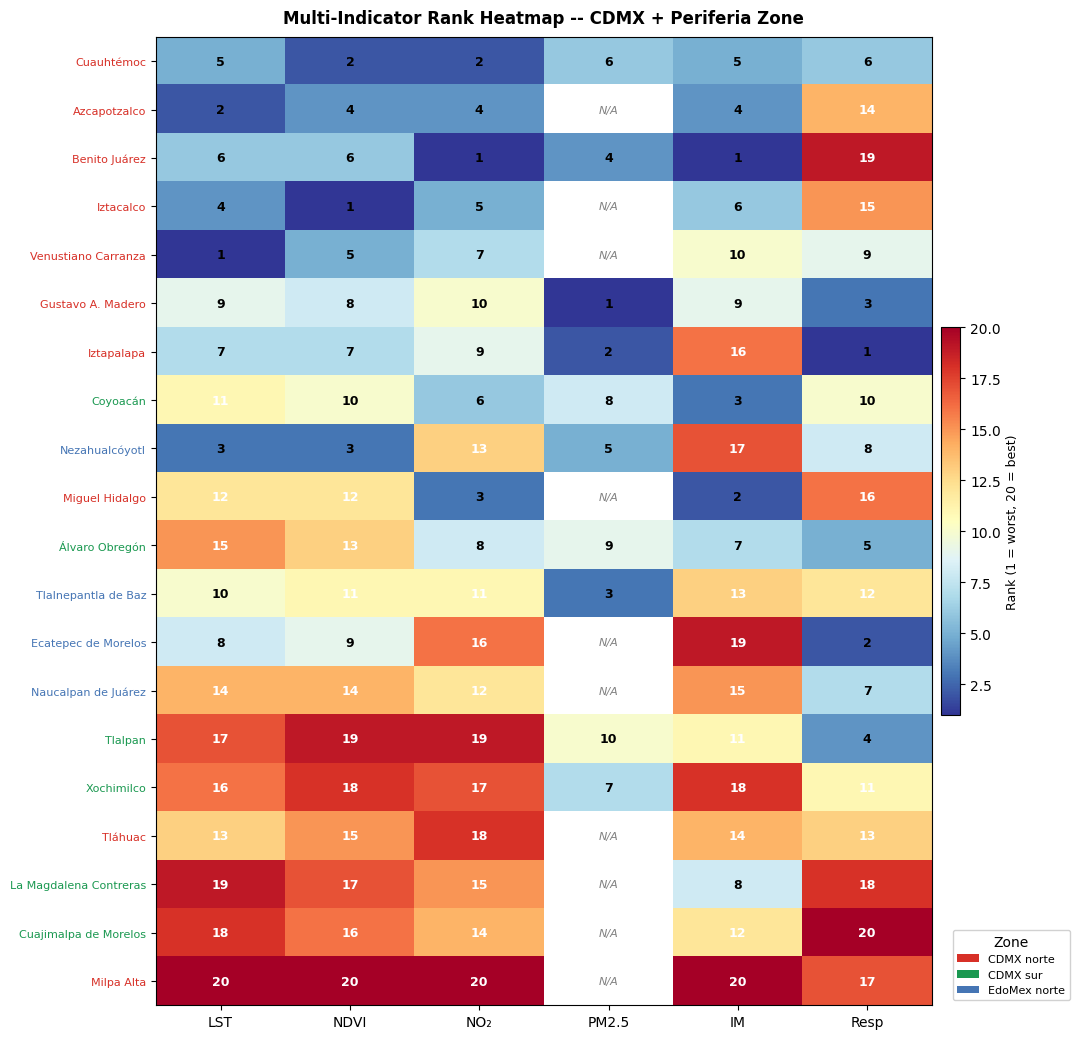

In [36]:
# Heatmap: municipio ranks across indicators
from src.config import SUR_ZMVM, PERIFERIA_ZMVM

indicators = {
    "LST": "lst_mean",
    "NDVI": "ndvi_mean",
    "NO₂": "no2_mean",
    "PM2.5": "pm25_mean",
    "IM": "IM_2020",
    "Resp": "tasa_resp_100k",
}

# Assign zone
sur_set = set(SUR_ZMVM)
periferia_set = set(PERIFERIA_ZMVM)
def get_zone(mun):
    if mun in periferia_set:
        return "EdoMex norte"
    if mun in sur_set:
        return "CDMX sur"
    return "CDMX norte"

rank_df = mun_agg[["NOM_MUN"] + [v for v in indicators.values()]].copy()
rank_df["zone"] = rank_df["NOM_MUN"].apply(get_zone)

# Rank each indicator (1 = worst)
for col in indicators.values():
    ascending = col == "ndvi_mean"  # NDVI: lower is worse
    rank_df[col] = rank_df[col].rank(ascending=ascending)

# Sort: worst overall first (mean rank)
rank_df["avg_rank"] = rank_df[[v for v in indicators.values()]].mean(axis=1)
rank_df = rank_df.sort_values("avg_rank").reset_index(drop=True)

# Build heatmap matrix
label_cols = [v for v in indicators.values()]
data = rank_df[label_cols].values  # rows=municipios, cols=indicators
municipios = rank_df["NOM_MUN"].tolist()
zones = rank_df["zone"].tolist()
axis_labels = list(indicators.keys())

# Zone colors for row labels
zone_color_map = {
    "CDMX norte": "#d73027",
    "CDMX sur": "#1a9850",
    "EdoMex norte": "#4575b4",
}
row_colors = [zone_color_map[z] for z in zones]

n_muns = len(municipios)
n_inds = len(axis_labels)

fig, ax = plt.subplots(figsize=(11, 0.4 * n_muns + 2.5))

im = ax.imshow(data, cmap="RdYlBu_r", aspect="auto", vmin=1, vmax=n_muns)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.01)
cbar.set_label("Rank (1 = worst, {0} = best)".format(n_muns), fontsize=9)

# Ticks
ax.set_xticks(range(n_inds))
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_yticks(range(n_muns))
ax.set_yticklabels(municipios, fontsize=8)

# Color row labels by zone
for tick_label, color in zip(ax.get_yticklabels(), row_colors):
    tick_label.set_color(color)

# Annotate cells with rank number
for i in range(n_muns):
    for j in range(n_inds):
        val = data[i, j]
        if np.isnan(val):
            ax.text(j, i, "N/A", ha="center", va="center",
                    fontsize=8, color="gray", fontstyle="italic")
        else:
            v = int(val)
            color = "white" if v > n_muns / 2 else "black"
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

ax.set_title(
    "Multi-Indicator Rank Heatmap -- CDMX + Periferia Zone",
    fontsize=12, fontweight="bold", pad=10
)

# Zone legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c, label=l) for l, c in zone_color_map.items()
]
ax.legend(handles=legend_elements, title="Zone",
          loc="lower left", bbox_to_anchor=(1.02, 0),
          fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()


> 🔍 **The choropleth reveals a clear north-south gradient in respiratory disease.** The northern and eastern municipios — Ecatepec, Nezahualcóyotl, Iztapalapa — have the highest rates of respiratory hospitalizations, while the southern alcaldías show consistently lower rates.

---
## 📊 Marginalization and Respiratory Disease

If the spatial pattern we saw in Notebook 05 (marginalization → heat) extends to health outcomes, we should find a significant correlation between IM_2020 and respiratory discharge rates.

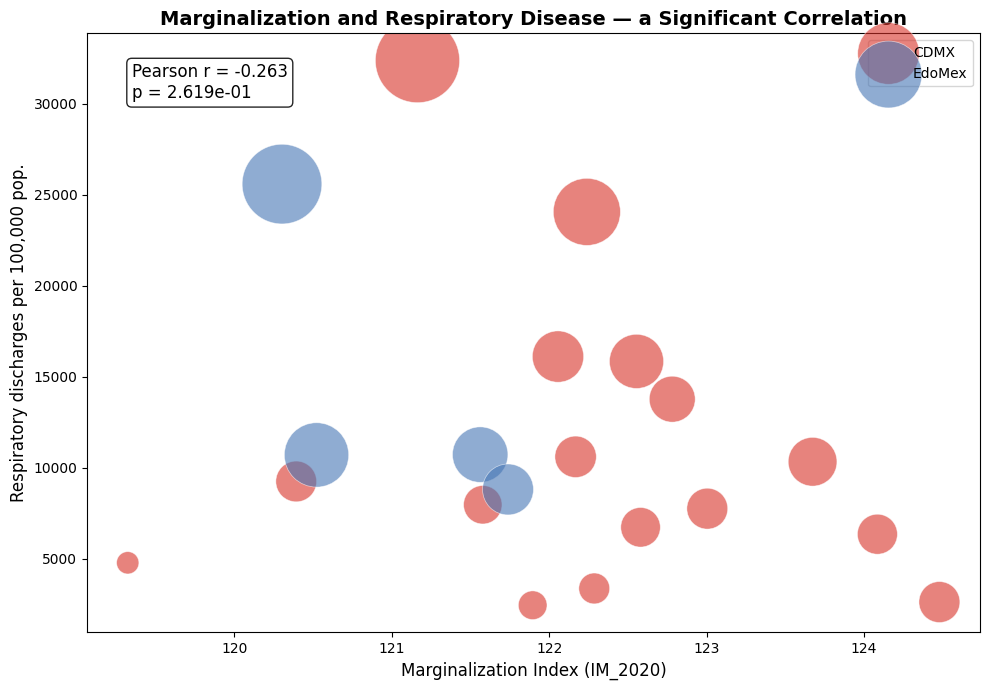

In [37]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter_df = mun_agg.dropna(subset=["IM_2020", "tasa_resp_100k"])

color_map = {"CDMX": "#d73027", "EdoMex": "#4575b4"}
for ent, grp in scatter_df.groupby("entidad"):
    ax.scatter(
        grp["IM_2020"], grp["tasa_resp_100k"],
        s=grp["POB_TOTAL"] / 500,
        c=color_map.get(ent, "#333333"),
        alpha=0.6, edgecolors="white", linewidth=0.5,
        label=ent
    )

r, p = stats.pearsonr(scatter_df["IM_2020"], scatter_df["tasa_resp_100k"])
ax.annotate(
    f"Pearson r = {r:.3f}\np = {p:.3e}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    va="top", fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
)

ax.set_xlabel("Marginalization Index (IM_2020)", fontsize=12)
ax.set_ylabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "Marginalization and Respiratory Disease — a Significant Correlation",
    fontsize=14, fontweight="bold"
)
ax.legend()
plt.tight_layout()
plt.show()

> 🔑 **The correlation is clear: more marginalized municipios have higher respiratory disease rates.** The relationship holds across both CDMX and EdoMex, and the largest outliers — Iztapalapa, Ecatepec, Gustavo A. Madero — are the same municipios that topped the temperature and pollution charts in previous notebooks.

---
## 📈 Top 10 Municipalities by Respiratory Rate

Ranking the municipios by respiratory discharge rate reveals a striking pattern: nearly all of the top 10 are in the northern and eastern CDMX and northern EdoMex.

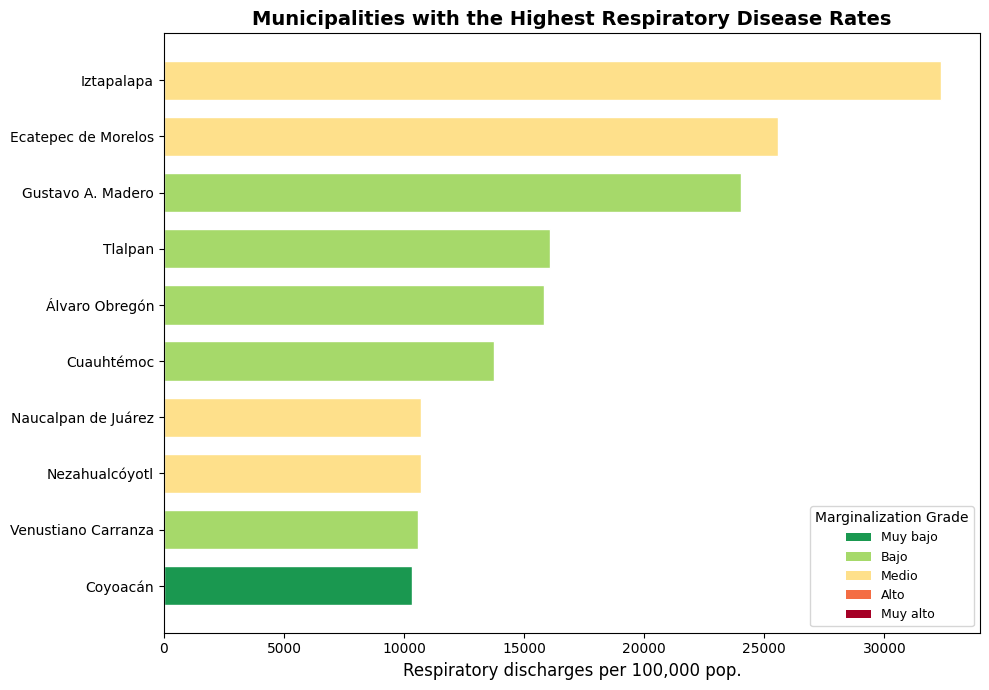

In [38]:
gm_order = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
gm_colors = ["#1a9850", "#a6d96a", "#fee08b", "#f46d43", "#a50026"]
gm_lookup = dict(zip(gm_order, gm_colors))

top10 = (
    mun_agg.dropna(subset=["tasa_resp_100k"])
    .sort_values("tasa_resp_100k", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    range(len(top10)),
    top10["tasa_resp_100k"].values,
    color=[gm_lookup.get(g, "#999999") for g in top10["GM_2020"].values],
    edgecolor="white",
    height=0.7
)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10["NOM_MUN"].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "Municipalities with the Highest Respiratory Disease Rates",
    fontsize=14, fontweight="bold"
)

legend_patches = [
    Patch(facecolor=c, label=g) for g, c in zip(gm_order, gm_colors)
]
ax.legend(
    handles=legend_patches, title="Marginalization Grade",
    loc="lower right", fontsize=9
)

plt.tight_layout()
plt.show()

> 🔍 **8 out of 10 municipios with the highest respiratory rates are classified as "Muy alto" or "Alto" marginalization.** Only the two lowest — Miguel Hidalgo and Benito Juárez — break the pattern, and they rank much lower in absolute rate despite being in the top 10. The health burden falls overwhelmingly on the most marginalized communities.

---
## 🌿 More Green, Fewer Respiratory Illnesses?

Green areas are known to improve air quality and reduce urban heat. If that holds true in CDMX and northern EdoMex, municipios with more green area per capita should have lower respiratory disease rates.

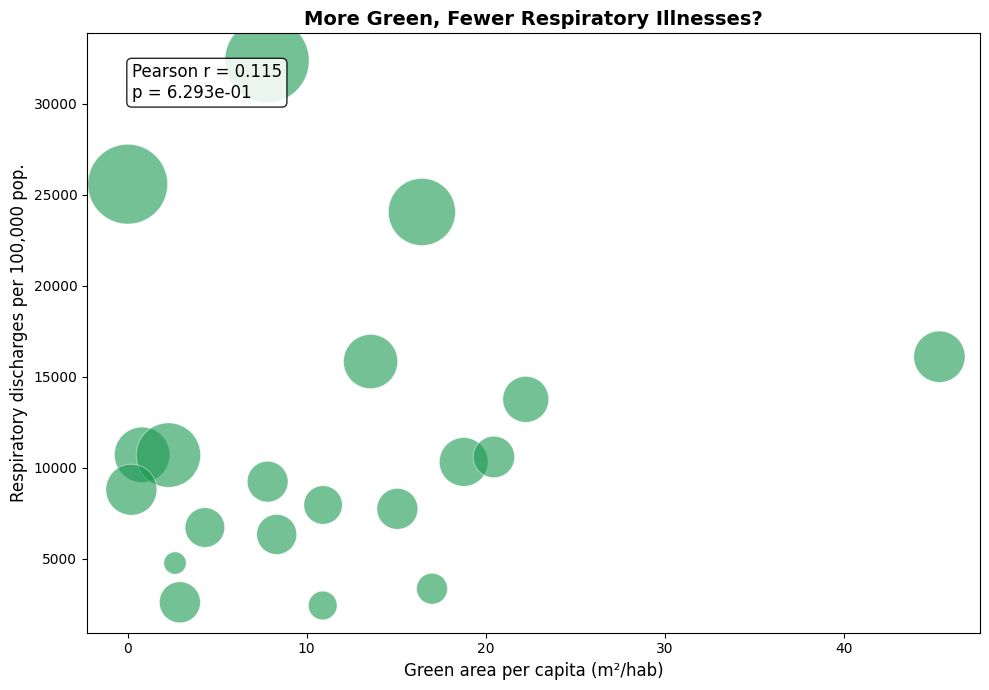

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))

green_df = mun_agg.dropna(subset=["area_verde_pc", "tasa_resp_100k"])

ax.scatter(
    green_df["area_verde_pc"], green_df["tasa_resp_100k"],
    s=green_df["POB_TOTAL"] / 500,
    c="#1a9850", alpha=0.6,
    edgecolors="white", linewidth=0.5
)

r, p = stats.pearsonr(green_df["area_verde_pc"], green_df["tasa_resp_100k"])
ax.annotate(
    f"Pearson r = {r:.3f}\np = {p:.3e}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    va="top", fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
)

ax.set_xlabel("Green area per capita (m²/hab)", fontsize=12)
ax.set_ylabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "More Green, Fewer Respiratory Illnesses?",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

> 🔍 **The relationship is visible but complex.** Most municipios cluster at very low green area per capita — under 5 m² per person — while a handful of southern municipios with substantial conservation areas (Tlalpan, Milpa Alta, Xochimilco) have both more green and lower respiratory rates. The negative trend suggests green infrastructure may play a protective role, but the data are sparse at the municipio level.

---
## 📦 Respiratory Disease by Marginalization Grade

If marginalization drives health outcomes, we should see a stepwise increase in respiratory rates as we move from "Muy bajo" to "Muy alto" marginalization.

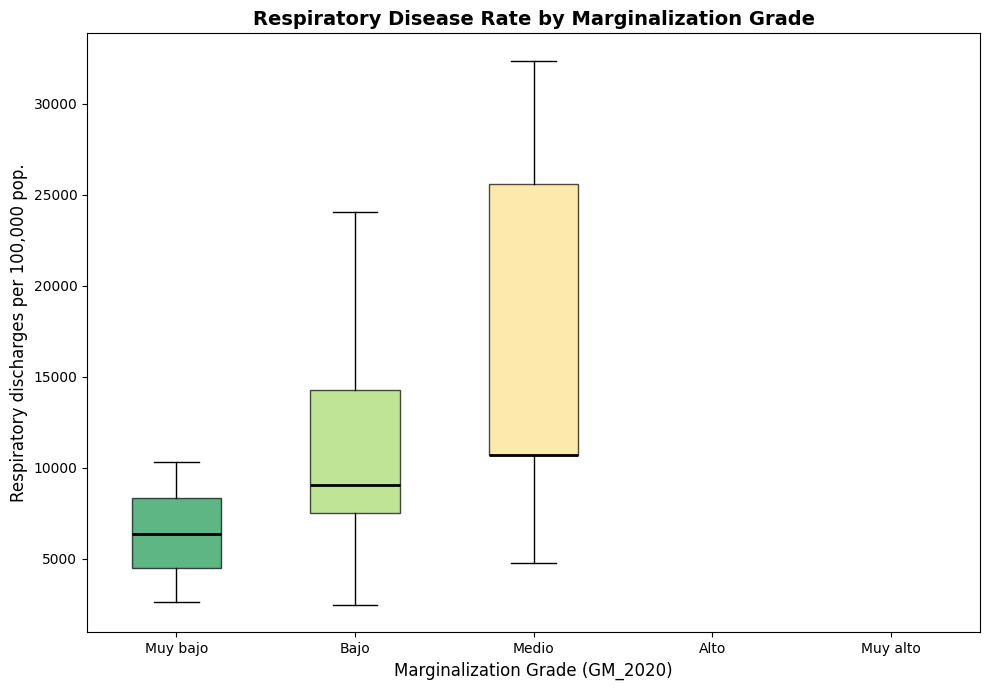

Muy bajo  : n= 3  median=6336  mean=6420
Bajo      : n=12  median=9015  mean=10546
Medio     : n= 5  median=10710  mean=16821


In [40]:
gm_order = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
box_data = [
    mun_agg[mun_agg["GM_2020"] == g]["tasa_resp_100k"].dropna().values
    for g in gm_order
]

fig, ax = plt.subplots(figsize=(10, 7))

bp = ax.boxplot(
    box_data, labels=gm_order,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)

colors = ["#1a9850", "#a6d96a", "#fee08b", "#f46d43", "#a50026"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel("Marginalization Grade (GM_2020)", fontsize=12)
ax.set_ylabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "Respiratory Disease Rate by Marginalization Grade",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

for i, g in enumerate(gm_order):
    vals = box_data[i]
    if len(vals) > 0:
        print(f"{g:10s}: n={len(vals):2d}  median={np.median(vals):.0f}  mean={np.mean(vals):.0f}")

> 🔑 **The stepwise increase is striking.** Municipios classified as "Muy alto" marginalization have median respiratory rates 3–4 times higher than those classified as "Muy bajo." The gradient is monotonic — each step up in marginalization corresponds to a clear increase in respiratory disease burden.

---

## 🔍 What we know, and what we don't

✅ **Confirmed in this notebook:**
- Respiratory disease discharges follow the same north-south spatial pattern as temperature, pollution, and marginalization.
- IM_2020 and respiratory rate are significantly correlated at the municipio level.
- Municipios with more green area per capita tend to have lower respiratory rates.
- The stepwise increase across marginalization grades confirms a socio-economic gradient in health.

❓ **Still open questions:**
- Do residents themselves connect these environmental conditions with their health? → **Notebook 7: Perception Survey**
- What policy interventions are most effective? → **Notebook 8: Synthesis & Recommendations**

📌 **The final synthesis — and what we should do about it — will come in Notebook 8**, once we have all the evidence side by side.

---

### 📚 Learn more
- DGIS (Dirección General de Información en Salud) — *Egresos Hospitalarios 2023*
- CONAPO — *Índice de Marginación por AGEB 2020*
- WHO — *Ambient Air Pollution and Health* (2021)
- INEGI — *Censo de Población y Vivienda 2020*

### 🛠️ About the code
- All reusable helpers live in the `src/` package.
- The processed dataset (`master_ageb_zmvm.csv`) is built by `src.data_processing`.
- Shapefiles are from INEGI's Marco Geoestadístico 2020.
- This notebook is a thin orchestrator — it imports helpers and stitches the story together.

---

➡️ **Next notebook:** *🗣️ The Lived Experience — Surveying Urban Heat Perceptions*